# PPO Algorithm

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement PPO or a simplified variant
- Train and stabilize policy optimization

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 3**.

---


## Lesson Brief

This lesson introduces **Proximal Policy Optimization (PPO)**, one of the most widely used deep RL algorithms.

Students should focus on the intuition: PPO improves a policy, but tries not to change it too aggressively in one update.

Why this matters: PPO is common in robotics, control, simulation, and RLHF-style training pipelines.

The main learning goal is to understand the stability idea before worrying about every implementation detail.

## Recommended YouTube Video

To reinforce this lesson, watch **Machine Learning with Phil - "Proximal Policy Optimization (PPO) is Easy With PyTorch | Full PPO Tutorial"**:
[Watch on YouTube](https://www.youtube.com/watch?v=hlv79rcHws0)

Why this pick:
- Clear English accent and practical PPO walkthrough.
- Covers the actor-critic background and the intuition behind constrained policy updates.
- Good fit for students who want both concept and implementation.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Clipped objective: limits oversized updates.
- Policy ratio: compares new and old action probabilities.
- Stable step: careful policy improvement.
- Update control: prevents destructive jumps.
- Bridge implementation: a simpler training example used to prepare students for the full PPO idea.

### Quick Check
- Why does PPO clip updates?
- What goes wrong if the policy changes too much?
- Why is PPO considered more stable than naive policy gradients?
- What part of this notebook is PPO intuition, and what part is a simpler bridge example?

### Common Mistakes
- Treating PPO as magic.
- Getting lost in the formula and missing the intuition.
- Thinking clipping alone solves everything.
- Assuming that every policy-gradient code example here is already a full PPO implementation.


## How to Read This Notebook Honestly

This notebook teaches **PPO intuition first** and uses a simpler policy-gradient training example as a bridge.

### What is the real teaching goal?

Students should leave understanding this idea:

`PPO tries to improve the policy, but not so aggressively that one update destroys what was already working.`

### What this notebook does well

- explains why uncontrolled policy updates can be dangerous
- introduces clipping as a stability idea
- connects PPO to the broader actor-critic and policy-gradient family

### What this notebook is not

This is **not** a full production-style PPO implementation.
The bridge code is simpler on purpose so students can focus on the stability idea before handling full PPO engineering details.

### Why keep that bridge?

Because many students understand PPO much better after first seeing a smaller policy-gradient loop they can actually trace line by line.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [1]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

"""
AIAT 123 - PPO Algorithm
PPO Algorithm
"""

# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt

# Print text to the notebook cell output (console).
print("=" * 70)
# Print text to the notebook cell output (console).
print("PPO Algorithm")
# Print text to the notebook cell output (console).
print("=" * 70)

# Implementation here
# Print text to the notebook cell output (console).
print("\n✅ Notebook ready for implementation!")


PPO Algorithm

✅ Notebook ready for implementation!


## 🌍 Bridge Example — REINFORCE Before PPO

**Industry context:**
- PPO is a more stable descendant of the same policy-gradient family
- Robotics and simulation systems often move from simple policy gradients toward PPO-style updates
- This example is a bridge for intuition, not a full PPO implementation

We implement **REINFORCE** on CartPole-v1 first, so students can understand policy-gradient learning before adding PPO's clipping and stability ideas.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


Episode   0 | Avg reward: 17.0
Episode  50 | Avg reward: 19.9


Episode 100 | Avg reward: 27.9


Episode 150 | Avg reward: 52.8


Episode 200 | Avg reward: 101.3


Episode 250 | Avg reward: 236.2


Episode 300 | Avg reward: 304.8


Episode 350 | Avg reward: 202.9


Episode 400 | Avg reward: 162.9


Episode 450 | Avg reward: 170.0


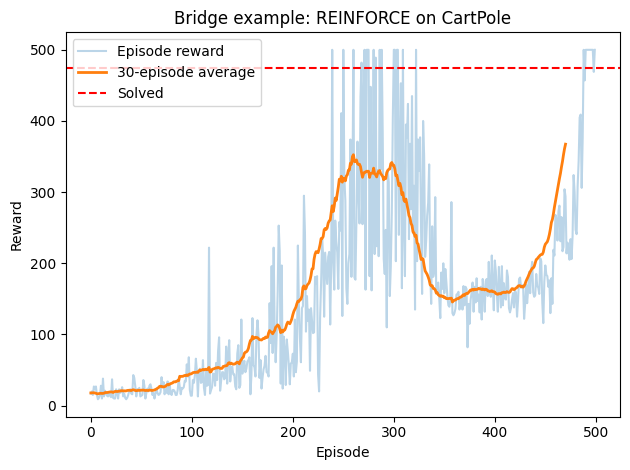

In [2]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Import names from a package/module into the notebook kernel namespace.
import torch, torch.nn as nn, torch.optim as optim
# Import names from a package/module into the notebook kernel namespace.
import gymnasium as gym
# Import names from a package/module into the notebook kernel namespace.
import numpy as np, matplotlib.pyplot as plt

# Call a PyTorch API (tensor/module/training-related).
torch.manual_seed(42)
# Assign/update a variable used later in this cell or in other cells.
env = gym.make('CartPole-v1')

# Class `PolicyNet` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class PolicyNet(nn.Module):
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def __init__(self):
        # Execute: super().__init__()
        super().__init__()
        # Assign/update a variable used later in this cell or in other cells.
        self.net = nn.Sequential(
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(4, 128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128, 2), nn.Softmax(dim=-1)
        # Close the parentheses opened earlier (end this function call / grouping).
        )
    # Function `forward` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, x.
    def forward(self, x): return self.net(x)

# Create or update the greedy policy array (one int action id per state).
policy  = PolicyNet()
# Assign/update a variable used later in this cell or in other cells.
opt     = optim.Adam(policy.parameters(), lr=2e-3)
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA   = 0.99; ep_rewards = []

# Loop header: repeat the indented block for each item in the iterable.
for episode in range(500):
    # Assign/update a variable used later in this cell or in other cells.
    obs,_ = env.reset(); log_probs=[]; rewards_ep=[]
    # Loop header: repeat the indented block for each item in the iterable.
    for _ in range(500):
        # Assign/update a variable used later in this cell or in other cells.
        probs  = policy(torch.tensor(obs).float().unsqueeze(0))
        # Assign/update a variable used later in this cell or in other cells.
        dist   = torch.distributions.Categorical(probs)
        # Assign/update a variable used later in this cell or in other cells.
        action = dist.sample()
        # Append one value to a list (mutates the list in place).
        log_probs.append(dist.log_prob(action))
        # Assign/update a variable used later in this cell or in other cells.
        obs, r, done, trunc, _ = env.step(action.item())
        # Append one value to a list (mutates the list in place).
        rewards_ep.append(r)
        # Branch: only run the next indented lines when this condition is true.
        if done or trunc: break

    # ── Compute discounted returns ──────────────────────────────────────────
    # Assign/update a variable used later in this cell or in other cells.
    G = 0; returns = []
    # Loop header: repeat the indented block for each item in the iterable.
    for r in reversed(rewards_ep):
        # Assign/update a variable used later in this cell or in other cells.
        G = r + GAMMA*G; returns.insert(0, G)
    # Assign/update a variable used later in this cell or in other cells.
    returns = torch.tensor(returns).float()
    # Assign/update a variable used later in this cell or in other cells.
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # ── Policy gradient loss ────────────────────────────────────────────────
    # Assign/update a variable used later in this cell or in other cells.
    loss = -torch.stack([lp*R for lp,R in zip(log_probs, returns)]).sum()
    # Execute: opt.zero_grad(); loss.backward(); opt.step()
    opt.zero_grad(); loss.backward(); opt.step()
    # Append one value to a list (mutates the list in place).
    ep_rewards.append(sum(rewards_ep))
    # Branch: only run the next indented lines when this condition is true.
    if episode%50==0: print(f"Episode {episode:3d} | Avg reward: {np.mean(ep_rewards[-20:]):.1f}")

# Execute: env.close()
env.close()
# Assign/update a variable used later in this cell or in other cells.
ma = np.convolve(ep_rewards, np.ones(30)/30, 'valid')
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.plot(ep_rewards, alpha=0.3, label="Episode reward")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.plot(ma, lw=2, label="30-episode average")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.axhline(475, color='red', linestyle='--', label="Solved")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.title("Bridge example: REINFORCE on CartPole")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.legend(); plt.tight_layout(); plt.show()


## 📚 References & Further Reading

**Papers:**
- Williams (1992) — [REINFORCE](https://link.springer.com/article/10.1007/BF00992696)
- Schulman et al. (2017) — [PPO: Proximal Policy Optimization](https://arxiv.org/abs/1707.06347)
- Mnih et al. (2016) — [A3C: Asynchronous Methods for Deep RL](https://arxiv.org/abs/1602.01783)

**State-of-the-Art:**
- OpenAI's ChatGPT uses RLHF (PPO) to align responses with human preferences
- Boston Dynamics robots use PPO for locomotion control

## 📝 Summary

You learned **Policy Gradient** methods that directly optimize the policy without a value table. **Actor-Critic** combines a policy (actor) with a value estimator (critic) for lower variance. **PPO** is today's most-used algorithm — it powers OpenAI's ChatGPT RLHF training and robotics at Boston Dynamics.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


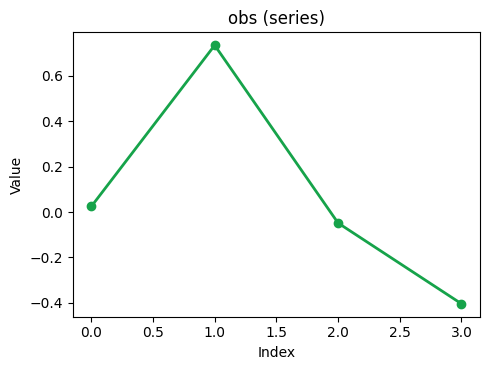

In [3]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Import names from a package/module into the notebook kernel namespace.
import numbers
# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Return a value from this function to its caller.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # Branch: only run the next indented lines when this condition is true.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Return a value from this function to its caller.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Loop header: repeat the indented block for each item in the iterable.
    for item in value.values():
        # Branch: only run the next indented lines when this condition is true.
        if not _is_number(item):
            # Return a value from this function to its caller.
            return None
        # Append one value to a list (mutates the list in place).
        converted.append(float(item))
    # Return a value from this function to its caller.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if array.ndim != dims:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 1 and not (2 <= array.size <= 200):
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 2 and array.size > 400:
        # Return a value from this function to its caller.
        return None
    # Return a value from this function to its caller.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math"}
# Assign/update a variable used later in this cell or in other cells.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Loop header: repeat the indented block for each item in the iterable.
for name in search_space:
    # Branch: only run the next indented lines when this condition is true.
    if name in seen or name not in globals() or name in skip_names:
        # Skip the rest of this loop body and jump to the next iteration.
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # Branch: only run the next indented lines when this condition is true.
    if dict_payload is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("dict", name, dict_payload))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # Branch: only run the next indented lines when this condition is true.
    if array_2d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("heatmap", name, array_2d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # Branch: only run the next indented lines when this condition is true.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("line", name, array_1d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break

# Branch: only run the next indented lines when this condition is true.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # Execute: "functions": sum(callable(value) for value in globals().values()),
        "functions": sum(callable(value) for value in globals().values()),
        # Execute: "classes": sum(isinstance(value, type) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # Execute: "numeric vars": sum(_is_number(value) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_title("Notebook artifact summary")
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.set_ylabel("Count")
    # Loop header: repeat the indented block for each item in the iterable.
    for idx, value in enumerate(summary.values()):
        # Configure a subplot axis (limits, ticks, labels, or artists).
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()
# Else branch: runs when the matching if/elif chain was not taken.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # Branch: only run the next indented lines when this condition is true.
    if len(candidates) == 1:
        # Assign/update a variable used later in this cell or in other cells.
        axes = [axes]

    # Loop header: repeat the indented block for each item in the iterable.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # Branch: only run the next indented lines when this condition is true.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.bar(range(len(values)), values, color="#2563eb")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticks(range(len(values)))
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (dict)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else-if branch: checked only when previous conditions were false.
        elif kind == "line":
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (series)")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_xlabel("Index")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_ylabel("Value")
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.set_title(f"{name} (heatmap)")
            # Configure or update the active Matplotlib Figure object.
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** PPO improves policy optimization by limiting overly large updates, making learning more stable in practice.

**If students remember one idea:** A good policy update should improve behavior without changing the policy so much that learning collapses.

**Quick check before moving on:**
- Can you explain why clipped updates help PPO remain stable?
- Can you describe how PPO builds on policy gradient and actor-critic ideas?

**Bridge to the next step:** After the core algorithms, students need to learn how to monitor training quality and diagnose weak runs.
